Question 2

In [6]:
!pip install librosa

In [26]:
import numpy as np
import librosa
import librosa.display
import soundfile as sf
from scipy import signal
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz, firwin, tf2zpk, periodogram
from numpy.polynomial import Polynomial

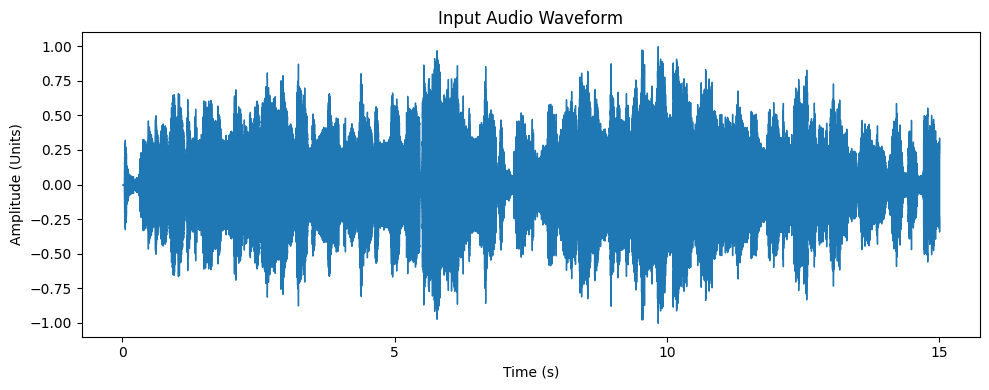

In [8]:
audio_path = "song_with_2piccolo.wav"
y, sr = librosa.load(audio_path,mono = True ,sr = None)
y_normalized = y / np.max(np.abs(y))

#Plotting Input waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y_normalized, sr=sr)
plt.title("Input Audio Waveform")
plt.ylabel("Amplitude (Units)")
plt.xlabel("Time (s)")
plt.tight_layout()
plt.savefig('Input_Audio.png')
plt.show()

Magnitude Spectrum

In [9]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

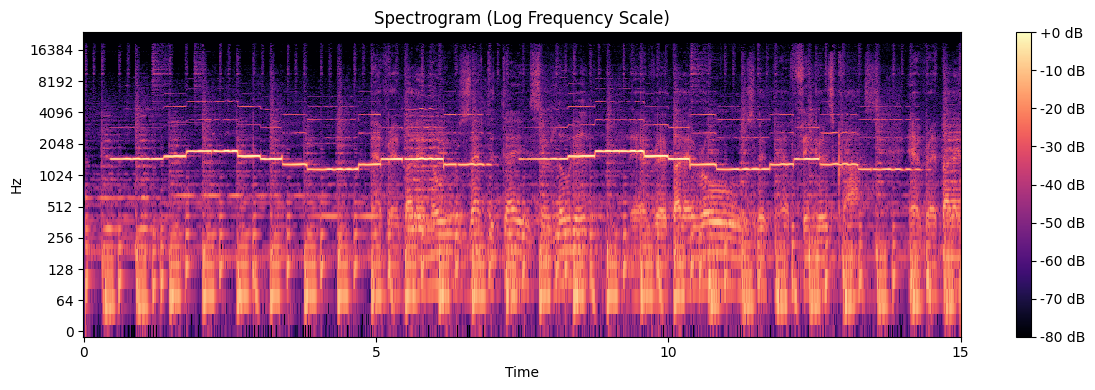

In [10]:
# Plotting Magnitude Spectrum
plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (Log Frequency Scale)")
plt.tight_layout()
plt.show()

Fourier Transform

In [11]:
n = len(y)
Y = np.fft.fft(y)
# Frequency bins for plotting
freqs = np.fft.fftfreq(n, d=1/sr)

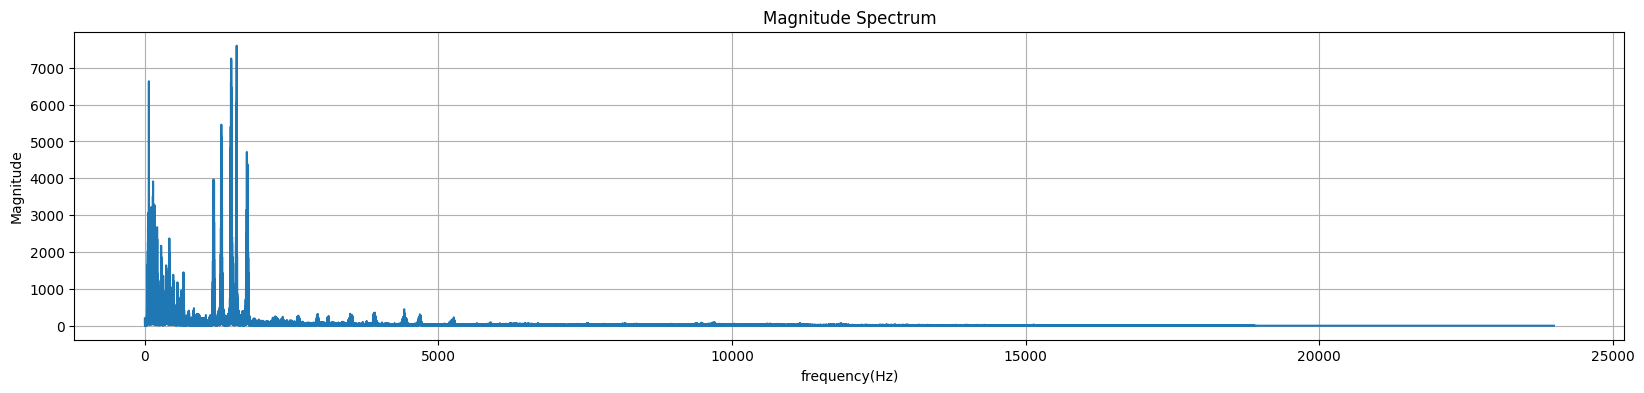

In [12]:
# Plotting
plt.figure(figsize=(20,4))
plt.plot(freqs[:len(freqs)//2],np.abs(Y)[:len(Y)//2])
plt.grid(True)
plt.title("Magnitude Spectrum")
plt.xlabel('frequency(Hz)')
plt.ylabel('Magnitude')
plt.show()

In [28]:
# Defining Frequency cuts
lowcut = 1150
highcut = 1750   # Cuts are defined manually on the hit and trial basis
nyq = 0.5 * sr
low = lowcut/nyq
high = highcut/nyq

#Using firwin from scipy.signal for FIR signals
numtaps = 1001  # Filter order + 1 # Higher value indicates more filters and thus more precision at some computational cost
fir_coeffs = firwin(numtaps, [low,high], pass_zero='bandpass', window='blackman')

y_filtered = lfilter(fir_coeffs, 1.0, y)
sf.write('Test.wav', y_filtered*5, sr)

In [27]:
def pole_zero(b, a):
    z, p, k = tf2zpk(b, a)

    t = np.linspace(0, 2*np.pi, 1000)
    unit_circle = np.exp(1j*t)

    plt.figure(figsize=(6, 6))
    plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')
    plt.scatter(np.real(z), np.imag(z), c='blue', marker='o', label='Zeros')
    plt.scatter(np.real(p), np.imag(p), c='red', marker='x', label='Poles')
    plt.title('Pole-Zero Plot')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

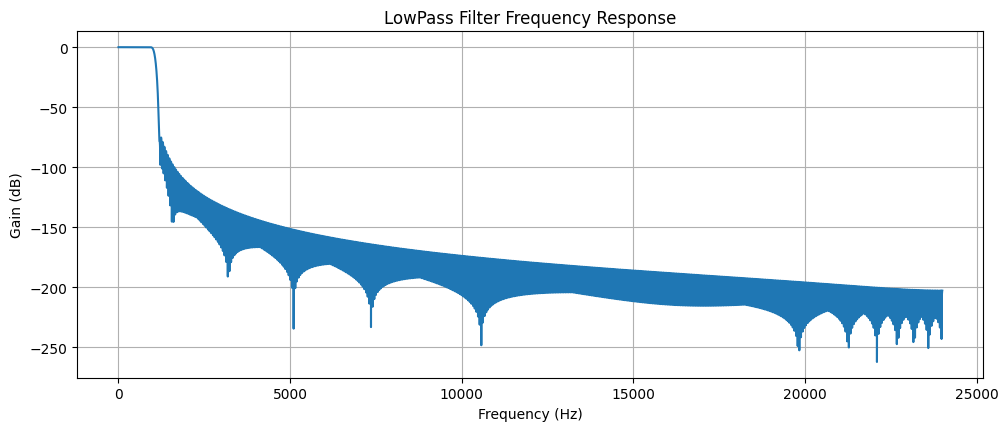

/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


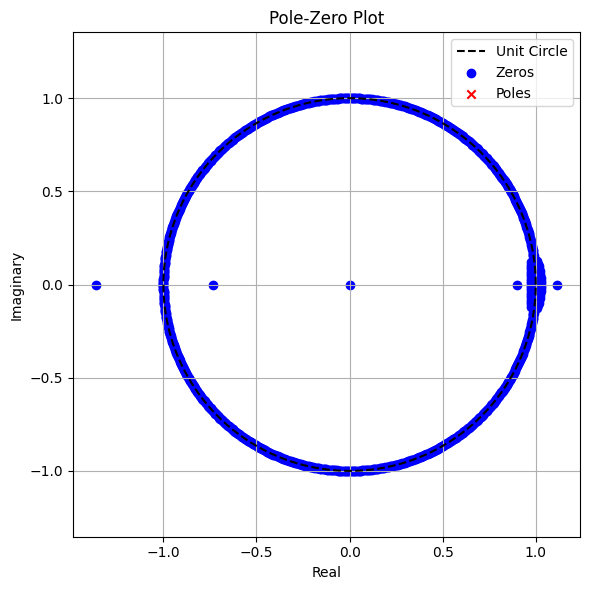

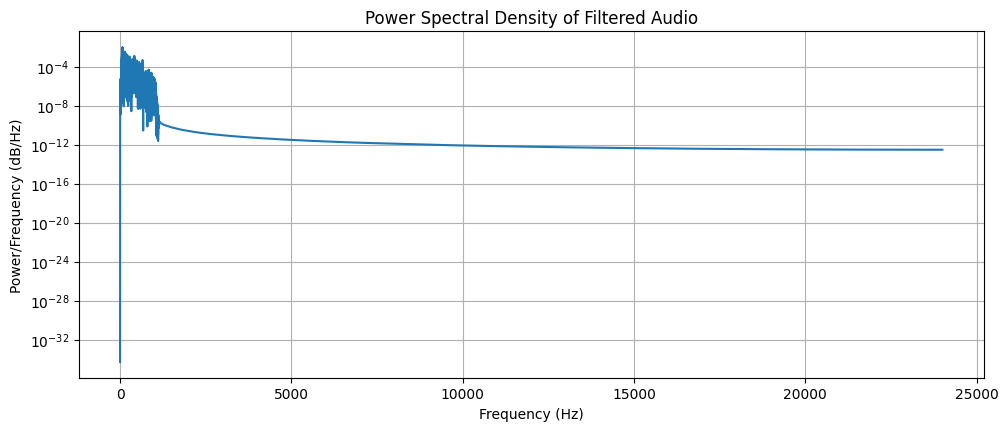

In [29]:
lowcut = 1050
nyq = 0.5 * sr
low = lowcut/nyq

numtaps = 1001 #this values was chosen on observing different values while also keeping in mind the computational cost
fir_coeffs = firwin(numtaps, low, pass_zero='lowpass', window='blackman')

y_filtered = lfilter(fir_coeffs, 1.0, y)
sf.write('lowpass.wav', y_filtered*3, sr)

#Visualising Bode-PLot
w, h = freqz(fir_coeffs, worN=10000)
plt.figure(figsize=(10, 4))
plt.plot((w / np.pi) * nyq, 20 * np.log10(abs(h)))
plt.grid(True)
plt.tight_layout()
plt.title("LowPass Filter Frequency Response")
plt.ylabel("Gain (dB)")
plt.xlabel("Frequency (Hz)")
plt.savefig('LowPass.png')
plt.show()

pole_zero(fir_coeffs,[1]) #since FIR no poles exist

# Compute Power Spectral Density
frequencies, psd = periodogram(y_filtered, sr)

# Plot Power Spectral Density
plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd)
plt.grid(True)
plt.tight_layout()
plt.title("Power Spectral Density of Filtered Audio")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.xlabel("Frequency (Hz)")
plt.show()

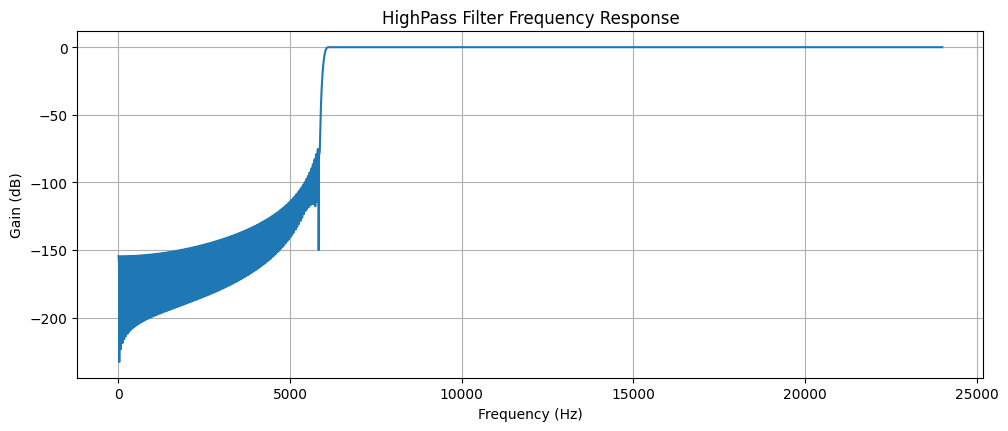

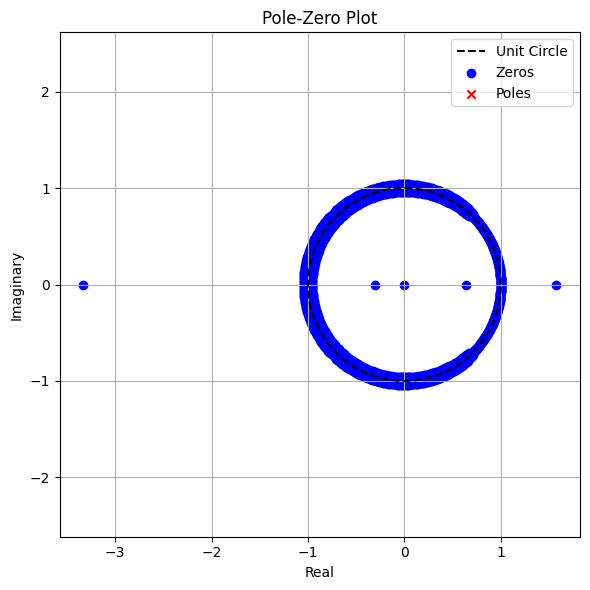

In [30]:
#High Pass filter to determine the end frequency piccolo tune
highcut = 6000

nyq = 0.5 * sr
high = highcut/nyq


numtaps = 1001  # Filter order + 1 # Higher
fir_coeffs = firwin(numtaps, high, pass_zero='highpass', window='blackman')

y_filtered = lfilter(fir_coeffs, 1.0, y)
sf.write('highpass.wav', y_filtered*2, sr)

#Visualising Bode-PLot
w, h = freqz(fir_coeffs, worN=10000)
plt.figure(figsize=(10, 4))
plt.plot((w / np.pi) * nyq, 20 * np.log10(abs(h)))
plt.grid(True)
plt.tight_layout()
plt.title("HighPass Filter Frequency Response")
plt.ylabel("Gain (dB)")
plt.xlabel("Frequency (Hz)")
plt.savefig('HighPass.png')
plt.show()

pole_zero(fir_coeffs,[1])

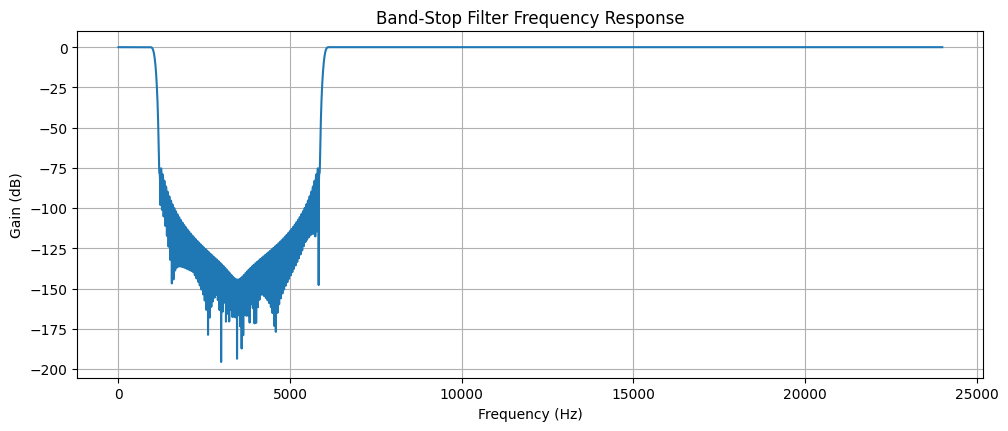

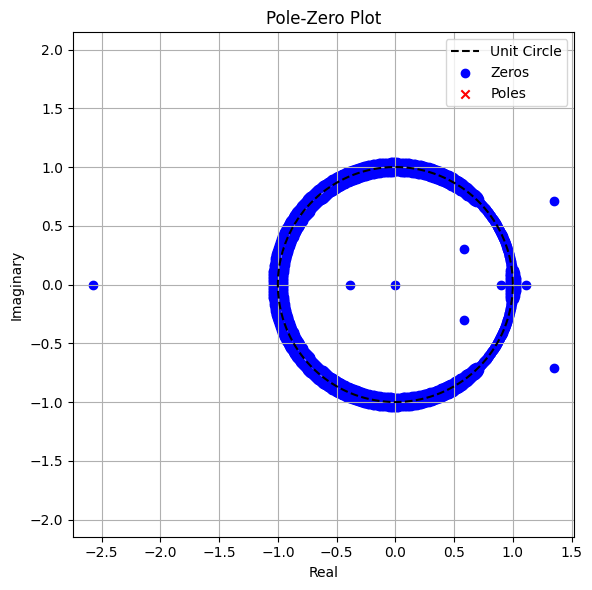

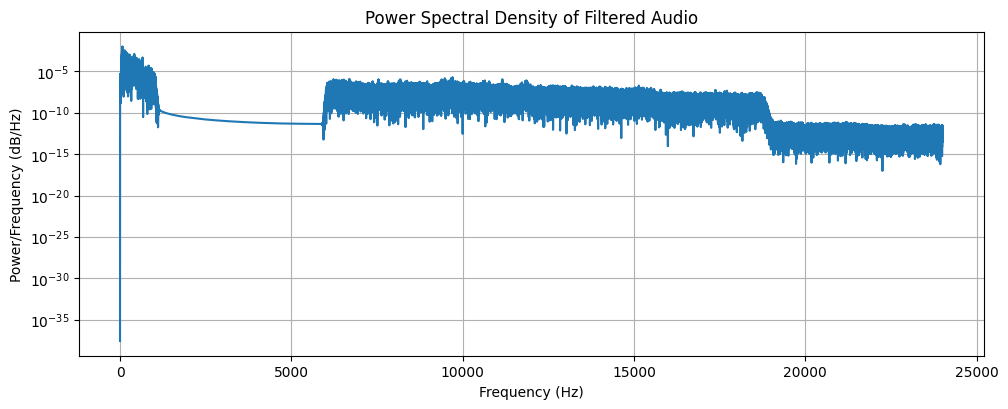

In [31]:
lowcut = 1050
highcut = 6000

nyq = 0.5 * sr
low = lowcut/nyq
high = highcut/nyq


numtaps = 1001  # Filter order + 1 , Higher
fir_coeffs = firwin(numtaps, [low, high], pass_zero='bandstop', window='blackman')

y_filtered = lfilter(fir_coeffs, 1.0, y)
sf.write('bandstop.wav', y_filtered*2, sr)

# Bode-PLot
w, h = freqz(fir_coeffs, worN=10000)

plt.figure(figsize=(10, 4))
plt.plot((w / np.pi) * nyq, 20 * np.log10(abs(h)))
plt.grid(True)
plt.tight_layout()
plt.title("Band-Stop Filter Frequency Response")
plt.ylabel("Gain (dB)")
plt.xlabel("Frequency (Hz)")
plt.savefig('Bandpass.png')
plt.show()

# Pole zero plot
b = fir_coeffs
a = [1]
pole_zero(b, a)

# Computing Power Spectral Density
frequencies, psd = periodogram(y_filtered, sr)

# Plot Power Spectral Density
plt.figure(figsize=(10, 4))
plt.semilogy(frequencies, psd)  # Use log scale for better visibility
plt.title("Power Spectral Density of Filtered Audio")
plt.grid(True)
plt.tight_layout()
plt.ylabel("Power/Frequency (dB/Hz)")
plt.xlabel("Frequency (Hz)")
plt.show()

Sample rate: 48000, Duration: 15.00 seconds


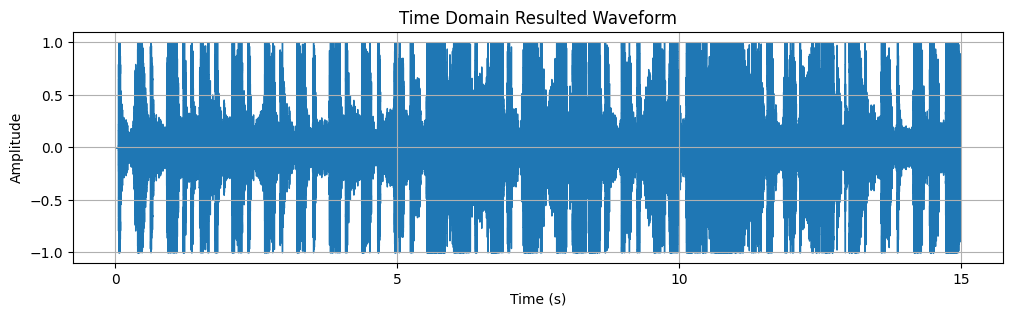

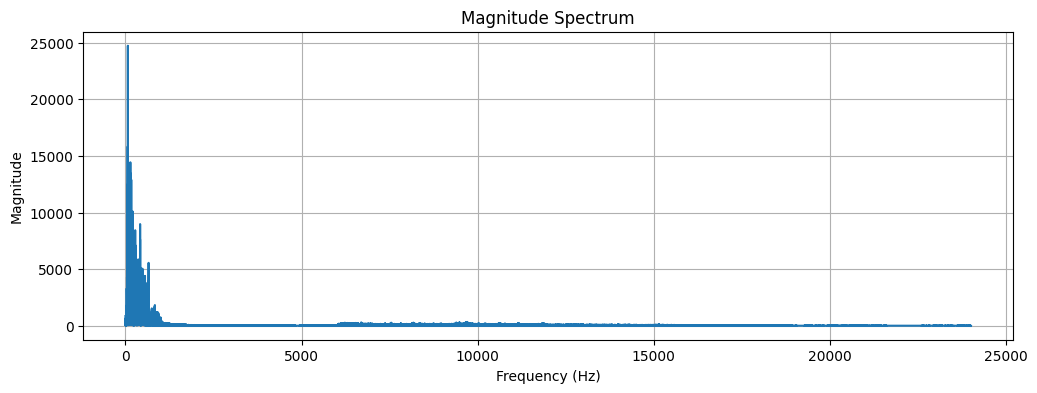

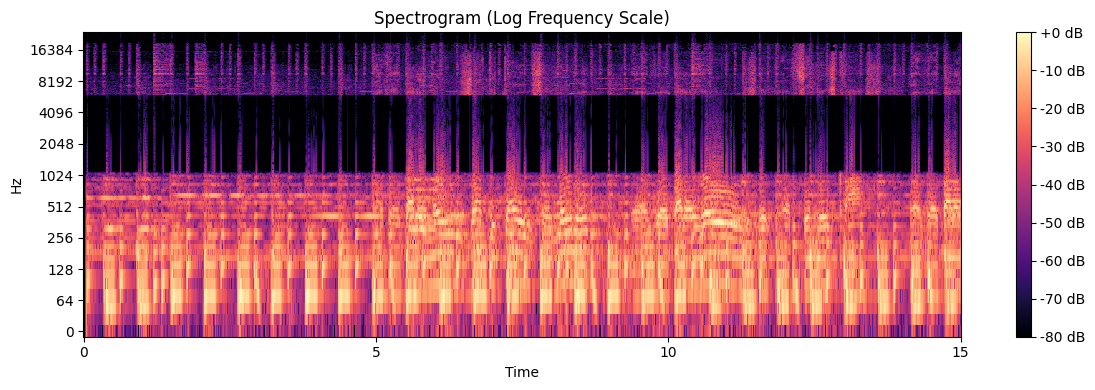

In [32]:
audio_path = 'bandstop.wav'
y, sr = librosa.load(audio_path, sr=None)
print(f"Sample rate: {sr}, Duration: {len(y)/sr:.2f} seconds")

y = y / np.max(np.abs(y))
nyq = 0.5 * sr

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Time Domain Resulted Waveform")
plt.grid(True)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.savefig('Onput_Audio.png')
plt.show()

Y = np.fft.fft(y)
frequencies = np.fft.fftfreq(len(Y), d=1/sr)

plt.figure(figsize=(12, 4))
plt.plot(frequencies[:len(frequencies)//2], np.abs(Y)[:len(Y)//2])
plt.grid(True)
plt.title("Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='magma')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (Log Frequency Scale)")
plt.tight_layout()
plt.show()

END

In [19]:
def pole_zero(b, a, title_suffix=''):
    z, p, k = tf2zpk(b, a)

    t = np.linspace(0, 2*np.pi, 1000)
    unit_circle = np.exp(1j*t)

    plt.figure(figsize=(6, 6))
    plt.plot(np.real(unit_circle), np.imag(unit_circle), 'k--', label='Unit Circle')
    plt.scatter(np.real(z), np.imag(z), c='blue', marker='o', label='Zeros')
    plt.scatter(np.real(p), np.imag(p), c='red', marker='x', label='Poles')
    plt.title(f'Pole-Zero Plot {title_suffix}')
    plt.xlabel('Real')
    plt.ylabel('Imaginary')
    plt.grid(True)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()